## Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("us_accidents_2020.csv")

In [3]:
df.head()

,Severity,Start_Time,End_Time,Distance(mi),City,County,State,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Astronomical_Twilight,Year,Duration,Hour,Month,Day,Road_Features
0,2,2020-12-28 05:55:31,2021-01-18 05:00:00,0.46,Atlantic City,Atlantic,NJ,43.0,74.0,30.13,10.0,S,8.0,0.0,clear,0,0,0,0,0,0,0,0,0,0,0,0,Day,2020,3000.000000,5,12,0,0
1,3,2020-12-31 22:57:02,2021-01-01 00:29:02,0.00,Addison,DuPage,IL,20.0,81.0,29.59,7.0,CALM,0.0,0.0,clear,0,0,0,0,0,0,0,0,0,0,0,0,Night,2020,92.000000,22,12,3,0
2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,0.00,Posen,Cook,IL,22.0,91.0,29.67,10.0,E,3.0,0.0,clear,0,0,0,0,0,0,0,0,0,0,0,0,Night,2020,219.633333,22,12,3,0
3,3,2020-12-31 22:58:36,2021-01-01 01:02:45,0.00,Chicago,Cook,IL,27.0,72.0,29.67,10.0,CALM,0.0,0.0,clear,0,0,1,0,0,0,0,0,0,0,0,1,Night,2020,124.150000,22,12,3,2
4,2,2020-12-31 23:32:07,2021-01-01 00:51:14,0.00,Denver,Denver,CO,28.0,69.0,24.39,10.0,CALM,0.0,0.0,clear,0,0,1,0,0,0,0,0,0,0,0,1,Night,2020,79.116667,23,12,3,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 34 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Severity               1178913 non-null  int64  
 1   Start_Time             1178913 non-null  object 
 2   End_Time               1178913 non-null  object 
 3   Distance(mi)           1178913 non-null  float64
 4   City                   1178913 non-null  object 
 5   County                 1178913 non-null  object 
 6   State                  1178913 non-null  object 
 7   Temperature(F)         1178913 non-null  float64
 8   Humidity(%)            1178913 non-null  float64
 9   Pressure(in)           1178913 non-null  float64
 10  Visibility(mi)         1178913 non-null  float64
 11  Wind_Direction         1178913 non-null  object 
 12  Wind_Speed(mph)        1178913 non-null  float64
 13  Precipitation(in)      1178913 non-null  float64
 14  Weather_Condition 

In [5]:
print(df.isna().sum())

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Year                     0
Duration                 0
Hour                     0
Month                    0
Day                      0
Road_Features            0
dtype: int64


In [6]:
df = df.drop(columns=["Start_Time", "End_Time", "Year"])

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Preproccessing

## Encoding

In [8]:
print(df[cat_cols].nunique().sort_values(ascending=False))

City                     9541
County                   1565
State                      49
Wind_Direction             10
Weather_Condition           6
Astronomical_Twilight       2
dtype: int64


In [9]:
le_cols = ["City", "County", "State"]
onehot_cols = ["Weather_Condition", "Wind_Direction", "Astronomical_Twilight"]

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in le_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

In [12]:
print(df.dtypes)

Severity                            int64
Distance(mi)                      float64
City                                int64
County                              int64
State                               int64
Temperature(F)                    float64
Humidity(%)                       float64
Pressure(in)                      float64
Visibility(mi)                    float64
Wind_Speed(mph)                   float64
Precipitation(in)                 float64
Amenity                             int64
Bump                                int64
Crossing                            int64
Give_Way                            int64
Junction                            int64
No_Exit                             int64
Railway                             int64
Roundabout                          int64
Station                             int64
Stop                                int64
Traffic_Calming                     int64
Traffic_Signal                      int64
Duration                          

In [13]:
print(df.shape)

(1178913, 43)


In [14]:
df.head(10)

,Severity,Distance(mi),City,County,State,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Duration,Hour,Month,Day,Road_Features,Weather_Condition_fog,Weather_Condition_hail,Weather_Condition_rain,Weather_Condition_snow,Weather_Condition_thunderstorm,Wind_Direction_E,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NW,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SW,Wind_Direction_VAR,Wind_Direction_W,Astronomical_Twilight_Night
0,2,0.46,313,61,29,43.0,74.0,30.13,10.0,8.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,3000.000000,5,12,0,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,3,0.00,30,426,12,20.0,81.0,29.59,7.0,0.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,92.000000,22,12,3,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,3,0.00,6862,331,12,22.0,91.0,29.67,10.0,3.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,219.633333,22,12,3,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,3,0.00,1475,331,12,27.0,72.0,29.67,10.0,0.0,0.00,0,0,1,0,0,0,0,0,0,0,0,1,124.150000,22,12,3,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,2,0.00,2112,399,4,28.0,69.0,24.39,10.0,0.0,0.00,0,0,1,0,0,0,0,0,0,0,0,1,79.116667,23,12,3,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
5,3,0.43,2112,399,4,34.0,41.0,24.41,10.0,5.0,0.00,0,0,0,0,1,0,0,0,0,0,0,0,78.333333,23,12,3,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
6,2,0.00,7658,730,45,46.0,89.0,29.43,7.0,10.0,0.02,0,0,1,0,0,0,0,0,0,0,0,1,81.300000,22,12,3,2,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
7,2,0.00,7658,730,45,46.0,93.0,30.04,10.0,6.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,90.316667,23,12,3,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
8,2,0.00,8170,1220,3,45.0,80.0,30.06,10.0,8.0,0.00,0,0,0,0,1,0,0,0,0,0,0,0,118.266667,20,12,3,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
9,2,0.00,8170,1220,3,54.0,57.0,30.06,10.0,10.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,337.900000,17,12,3,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


## Data Splitting

In [15]:
from sklearn.model_selection import train_test_split

target = "Severity"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Train set size: 825239
Test set size: 353674


## Feature Selection

### Numerical Feature Selection

In [16]:
# Ambil kolom boolean (hasil one-hot)
binary_cols = [col for col in X_train.columns if X_train[col].dtype == 'bool']

numerical_features = [
    col for col in X_train.columns
    if col not in cat_cols
    and col not in binary_cols
]

# Gabungkan dengan target untuk korelasi
subset_df = pd.concat([X_train[numerical_features], y_train], axis=1)

# Hitung Pearson correlation
pearson_corr = subset_df.corr(method='pearson')[target].drop(target)

# Hitung Spearman correlation
spearman_corr = subset_df.corr(method='spearman')[target].drop(target)

# Gabungkan ke DataFrame
num_corr_df = pd.DataFrame({
    "Feature": pearson_corr.index,
    "Pearson": pearson_corr.values,
    "Spearman": spearman_corr.values
})

# Tambahkan absolut value
num_corr_df["Pearson_abs"] = num_corr_df["Pearson"].abs()
num_corr_df["Spearman_abs"] = num_corr_df["Spearman"].abs()

# Sort berdasarkan Spearman (lebih robust)
num_corr_df = num_corr_df.sort_values(by="Spearman_abs", ascending=False)

print("=== Numerical Feature Correlation ===")
display(num_corr_df)

=== Numerical Feature Correlation ===


,Feature,Pearson,Spearman,Pearson_abs,Spearman_abs
19,Duration,-0.038317,-0.146892,0.038317,0.146892
18,Traffic_Signal,-0.118222,-0.126731,0.118222,0.126731
23,Road_Features,-0.115701,-0.125551,0.115701,0.125551
9,Crossing,-0.110815,-0.118725,0.110815,0.118725
21,Month,-0.096152,-0.109025,0.096152,0.109025
5,Wind_Speed(mph),0.047462,0.057387,0.047462,0.057387
6,Precipitation(in),0.037091,0.052886,0.037091,0.052886
0,Distance(mi),0.104060,-0.044482,0.104060,0.044482
16,Stop,-0.036248,-0.041951,0.036248,0.041951
15,Station,-0.032934,-0.036227,0.032934,0.036227


### Categorical Feature Selection

In [17]:
from scipy.stats import chi2_contingency
import numpy as np

def calculate_cramers_v(chi2, n, shape):
    r, c = shape
    return np.sqrt(chi2 / (n * (min(r - 1, c - 1))))

# Ambil fitur kategorikal (yang sudah di-encode sebagai int/bool)
categorical_features = [col for col in X.columns if col not in numerical_features]

results = []
n = len(df)

for feature in categorical_features:

    # Buat tabel kontingensi
    contingency = pd.crosstab(X_train[feature], y_train)

    # Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Hitung Cramer's V
    v = calculate_cramers_v(chi2, n, contingency.shape)

    results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p,
        "Cramers_V": v
    })

cat_corr_df = pd.DataFrame(results).sort_values(by="Cramers_V", ascending=False)

print("=== Categorical Feature Association ===")
display(cat_corr_df)

=== Categorical Feature Association ===


,Feature,Chi2,p_value,Cramers_V
0,City,301926.181282,0.000000e+00,0.292179
1,County,219616.323678,0.000000e+00,0.249190
2,State,126453.786912,0.000000e+00,0.189088
17,Astronomical_Twilight_Night,19152.195232,0.000000e+00,0.127458
7,Weather_Condition_thunderstorm,1961.141916,0.000000e+00,0.040786
5,Weather_Condition_rain,1949.180393,0.000000e+00,0.040662
12,Wind_Direction_S,931.121805,1.571730e-201,0.028104
16,Wind_Direction_W,875.517603,1.808572e-189,0.027252
3,Weather_Condition_fog,846.064477,4.421680e-183,0.026789
14,Wind_Direction_SW,308.316227,1.576965e-66,0.016172


### Mutual Information

In [18]:
from sklearn.feature_selection import mutual_info_classif

# Tentukan fitur diskrit
discrete_mask = [col in categorical_features for col in X_train.columns]

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    discrete_features=discrete_mask,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

print("=== Mutual Information ===")
display(mi_df)

=== Mutual Information ===


,Feature,MI_Score
22,Duration,0.135062
1,City,0.130881
7,Visibility(mi),0.119179
2,County,0.101303
0,Distance(mi),0.083280
24,Month,0.072362
3,State,0.057313
26,Road_Features,0.023160
21,Traffic_Signal,0.022377
23,Hour,0.019754


### Combined Importance


In [19]:
# Merge semua hasil
master_df = mi_df.copy()

master_df = pd.merge(master_df, num_corr_df, on="Feature", how="left")
master_df = pd.merge(master_df, cat_corr_df, on="Feature", how="left")

# Isi NaN dengan 0
master_df = master_df.fillna(0)

def normalize(series):
    s = series.copy()
    valid = s.dropna()

    if len(valid) == 0:
        return s

    if valid.max() == valid.min():
        s.loc[valid.index] = 1.0
        return s

    s.loc[valid.index] = (valid - valid.min()) / (valid.max() - valid.min())
    return s

master_df["MI_norm"] = normalize(master_df["MI_Score"])
master_df["Pearson_norm"] = normalize(master_df["Pearson_abs"])
master_df["Spearman_norm"] = normalize(master_df["Spearman_abs"])
master_df["CramersV_norm"] = normalize(master_df["Cramers_V"])

# Transform p-value → significance score
eps = 1e-10
master_df["Chi2_score"] = -np.log10(master_df["p_value"] + eps)
master_df["Chi2_norm"] = normalize(master_df["Chi2_score"])

master_df["Combined_Importance"] = master_df[
    ["MI_norm", "Pearson_norm", "Spearman_norm", "CramersV_norm", "Chi2_norm"]
].mean(axis=1)

master_df = master_df.sort_values(by="Combined_Importance", ascending=False)

print("=== Final Feature Ranking ===")
display(master_df.tail(20))

=== Final Feature Ranking ===


,Feature,MI_Score,Pearson,Spearman,Pearson_abs,Spearman_abs,Chi2,p_value,Cramers_V,MI_norm,Pearson_norm,Spearman_norm,CramersV_norm,Chi2_score,Chi2_norm,Combined_Importance
32,Railway,0.000127,-0.012479,-0.013284,0.012479,0.013284,0.000000,0.000000e+00,0.000000,0.000939,0.105556,0.090434,0.000000,10.00000,1.00000,0.239386
21,Weather_Condition_rain,0.001093,0.000000,0.000000,0.000000,0.000000,1949.180393,0.000000e+00,0.040662,0.008094,0.000000,0.000000,0.139167,10.00000,1.00000,0.229452
22,Weather_Condition_thunderstorm,0.000960,0.000000,0.000000,0.000000,0.000000,1961.141916,0.000000e+00,0.040786,0.007106,0.000000,0.000000,0.139593,10.00000,1.00000,0.229340
30,No_Exit,0.000195,-0.008325,-0.008468,0.008325,0.008468,0.000000,0.000000e+00,0.000000,0.001444,0.070421,0.057647,0.000000,10.00000,1.00000,0.225902
24,Wind_Direction_S,0.000547,0.000000,0.000000,0.000000,0.000000,931.121805,1.571730e-201,0.028104,0.004051,0.000000,0.000000,0.096186,10.00000,1.00000,0.220048
26,Wind_Direction_W,0.000486,0.000000,0.000000,0.000000,0.000000,875.517603,1.808572e-189,0.027252,0.003595,0.000000,0.000000,0.093270,10.00000,1.00000,0.219373
23,Weather_Condition_fog,0.000619,0.000000,0.000000,0.000000,0.000000,846.064477,4.421680e-183,0.026789,0.004585,0.000000,0.000000,0.091688,10.00000,1.00000,0.219254
27,Give_Way,0.000417,-0.004951,-0.006489,0.004951,0.006489,0.000000,0.000000e+00,0.000000,0.003087,0.041879,0.044178,0.000000,10.00000,1.00000,0.217829
31,Wind_Direction_SW,0.000168,0.000000,0.000000,0.000000,0.000000,308.316227,1.576965e-66,0.016172,0.001246,0.000000,0.000000,0.055349,10.00000,1.00000,0.211319
29,Weather_Condition_snow,0.000239,0.000000,0.000000,0.000000,0.000000,289.781903,1.618550e-62,0.015678,0.001766,0.000000,0.000000,0.053659,10.00000,1.00000,0.211085


### Feature Recommendation

In [20]:
top_n = 15

recommended_features = master_df.head(top_n)["Feature"].tolist()

print("Jumlah fitur terpilih:", len(recommended_features))
print("Fitur terbaik:")
print(recommended_features)

Jumlah fitur terpilih: 15
Fitur terbaik:
['Duration', 'Month', 'Traffic_Signal', 'Road_Features', 'City', 'Crossing', 'Distance(mi)', 'County', 'Visibility(mi)', 'State', 'Wind_Speed(mph)', 'Precipitation(in)', 'Stop', 'Hour', 'Astronomical_Twilight_Night']


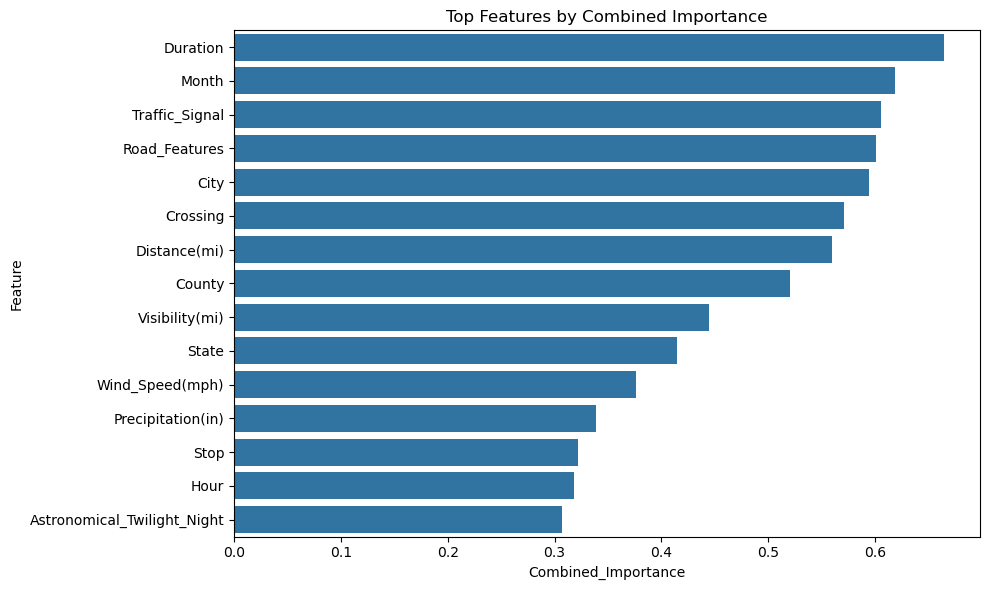

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=master_df.head(top_n),
    x="Combined_Importance",
    y="Feature"
)

plt.title("Top Features by Combined Importance")
plt.tight_layout()
plt.show()

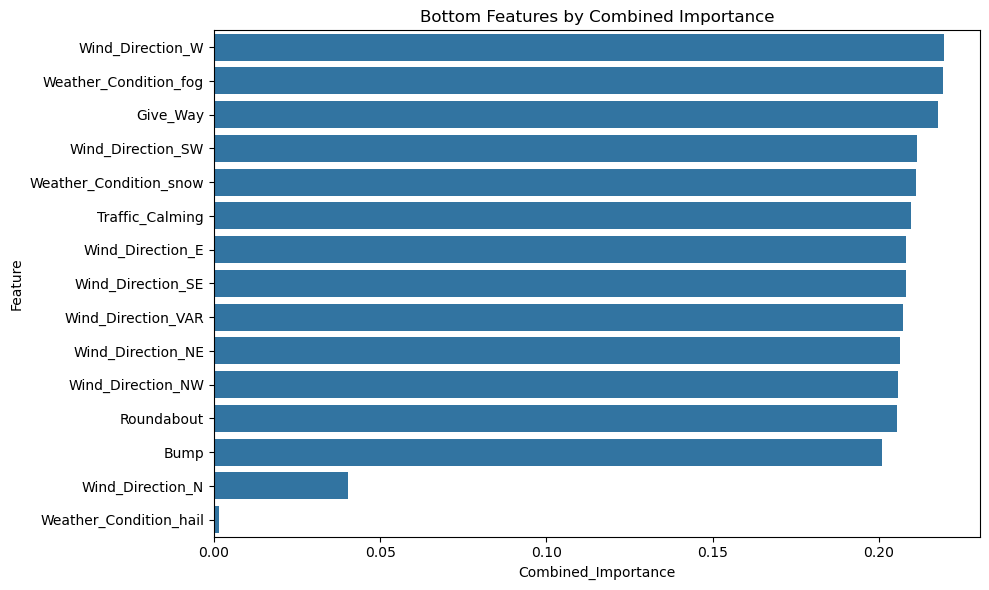

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=master_df.tail(top_n),
    x="Combined_Importance",
    y="Feature"
)
plt.title("Bottom Features by Combined Importance")
plt.tight_layout()
plt.show()

## Feature Scaling

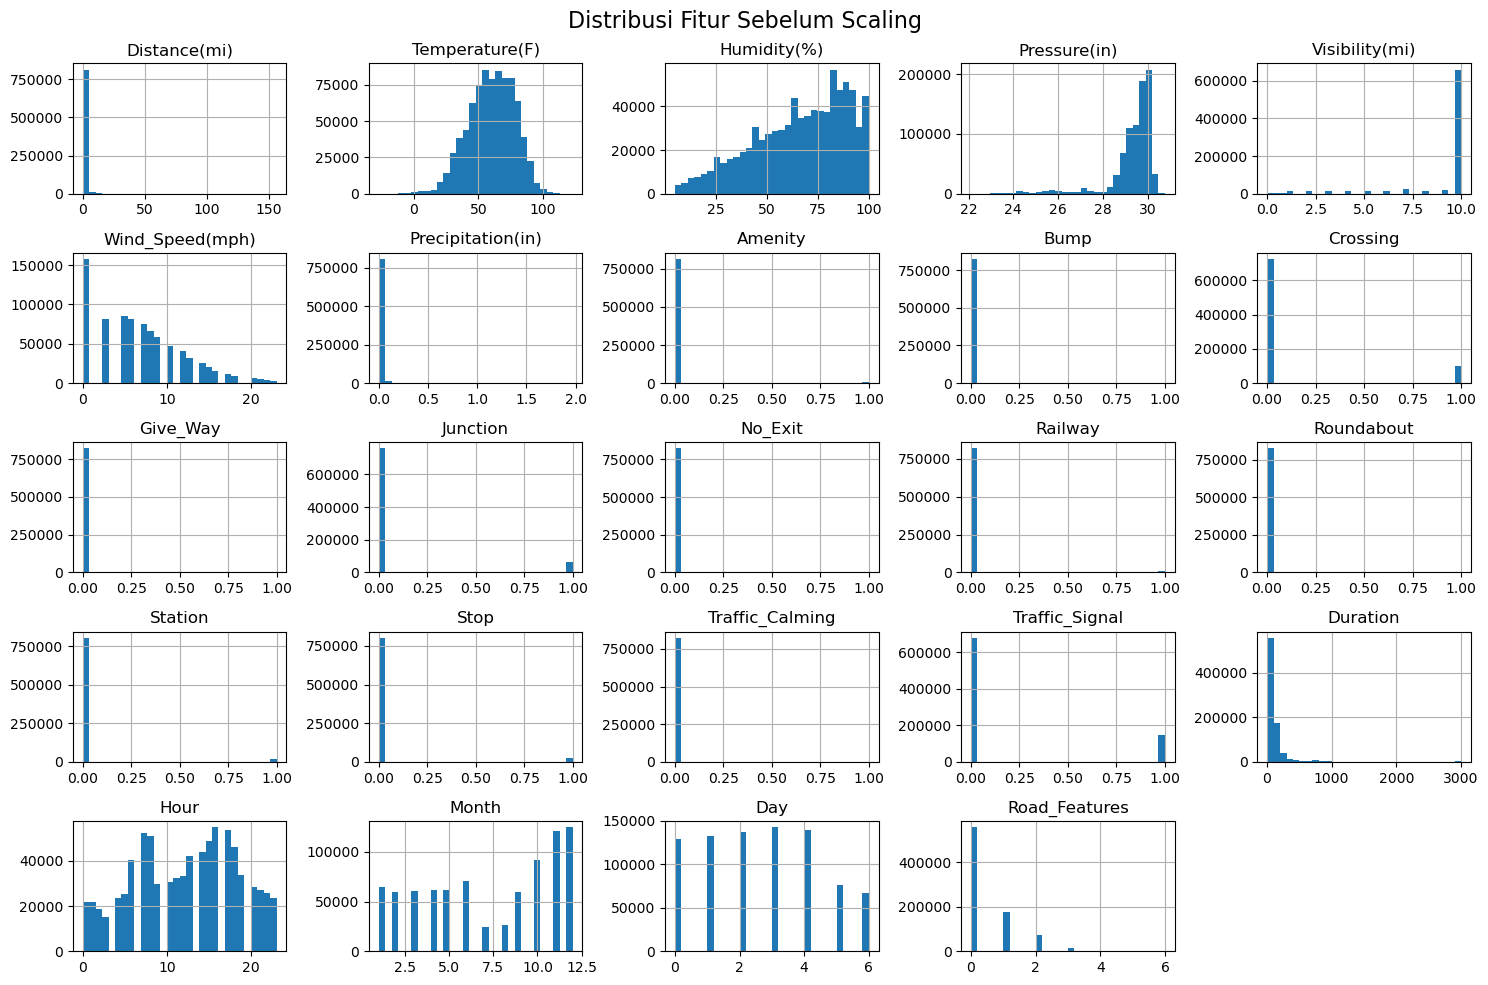

In [23]:
import matplotlib.pyplot as plt

# Plot beberapa fitur numerikal
X_train[numerical_features].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribusi Fitur Sebelum Scaling", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

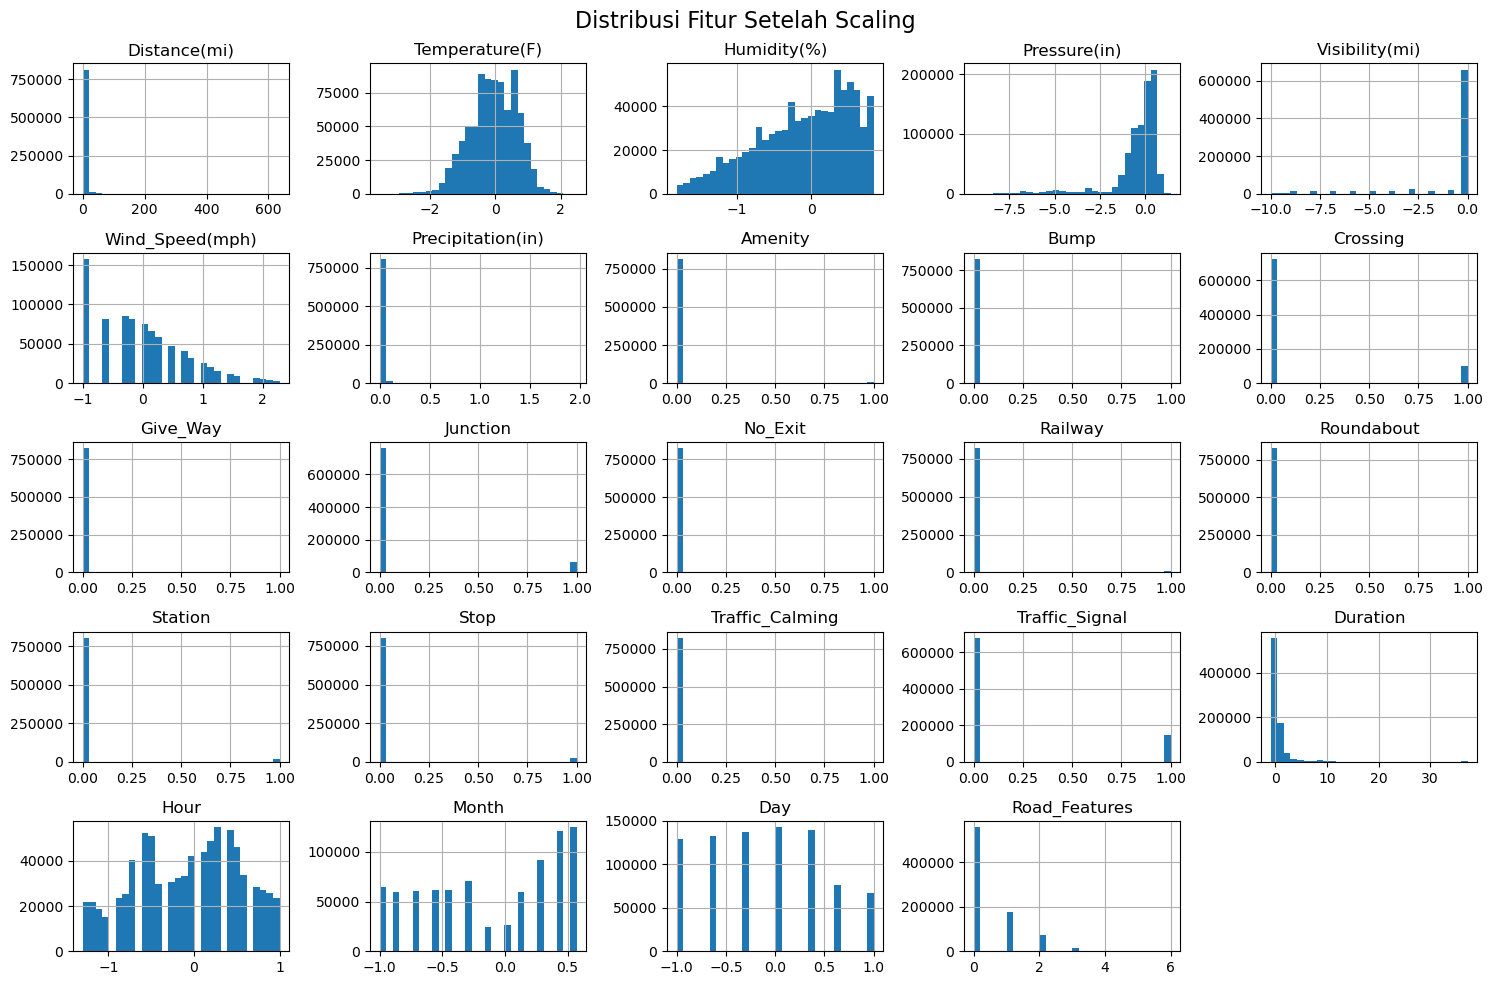

In [25]:
X_train_scaled[numerical_features].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribusi Fitur Setelah Scaling", fontsize=16)
plt.tight_layout()
plt.show()

## Balancing Target

In [26]:
y_train.value_counts()

Severity
2    653886
3    129746
4     21747
1     19860
Name: count, dtype: int64

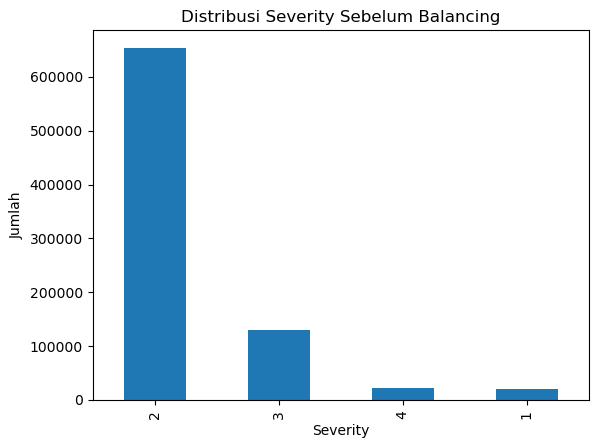

In [27]:
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind='bar')
plt.title("Distribusi Severity Sebelum Balancing")
plt.xlabel("Severity")
plt.ylabel("Jumlah")
plt.show()

### Undersampling

In [28]:
X_train_scaled = X_train.drop(columns= ['Bump', 'Traffic_Calming', 'Roundabout', 'Give_Way', 'No_Exit', 'Railway'])
X_test_scaled = X_test.drop(columns= ['Bump', 'Traffic_Calming', 'Roundabout', 'Give_Way', 'No_Exit', 'Railway'])

In [29]:
from imblearn.under_sampling import RandomUnderSampler

print("Class distribution before undersampling:")
print(y_train.value_counts())

undersample = RandomUnderSampler(sampling_strategy={2: y.value_counts()[2] // 4}, random_state=42)

X_under, y_under = undersample.fit_resample(
    X_train_scaled,
    y_train
)

# Show class distribution after undersampling
print("\nUndersampling complete.")
print("Class distribution after undersampling:")
print(y_under.value_counts())

Class distribution before undersampling:
Severity
2    653886
3    129746
4     21747
1     19860
Name: count, dtype: int64

Undersampling complete.
Class distribution after undersampling:
Severity
2    233530
3    129746
4     21747
1     19860
Name: count, dtype: int64


### Oversampling (SMOTE)

Class distribution before SMOTE:
Severity
2    233530
3    129746
4     21747
1     19860
Name: count, dtype: int64

SMOTE complete.
Class distribution after SMOTE:
Severity
2    233530
3    185000
1    180000
4    180000
Name: count, dtype: int64


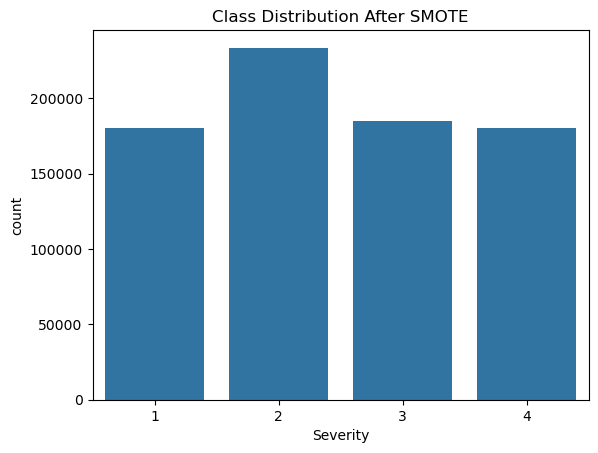

In [30]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_under.value_counts())


sampling_strategy = {
    1: max(180000, y_train.value_counts()[1]),
    3: max(185000, y_train.value_counts()[3]),
    4: max(180000, y_train.value_counts()[4])
}

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)

X_balanced, y_balanced = smote.fit_resample(
    X_under,
    y_under
)

print("\nSMOTE complete.")
print("Class distribution after SMOTE:")
print(y_balanced.value_counts())

sns.countplot(x=y_balanced)
plt.title("Class Distribution After SMOTE")
plt.show()

### Distribusi Setelah Balancing

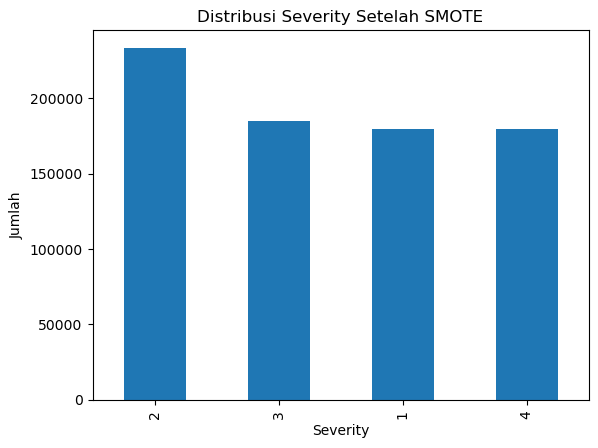

In [31]:
y_balanced.value_counts().plot(kind='bar')
plt.title("Distribusi Severity Setelah SMOTE")
plt.xlabel("Severity")
plt.ylabel("Jumlah")
plt.show()

# Modeling

In [32]:
!pip install xgboost lightgbm catboost optuna -q

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     learning_curve, train_test_split)
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED        = 42
CLASS_NAMES = ["1", "2", "3", "4"]
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

PALETTE = {
    "Logistic Regression": "#4C72B0",
    "Random Forest":       "#DD8452",
    "XGBoost":             "#55A868",
    "LightGBM":            "#C44E52",
}

print("Setup complete.")
print(f"X_train: {X_balanced.shape} | X_test: {X_test.shape}")
print(f"Class distribution (train):\n{pd.Series(y_balanced).value_counts()}")

Setup complete.
X_train: (778530, 36) | X_test: (353674, 42)
Class distribution (train):
Severity
2    233530
3    185000
1    180000
4    180000
Name: count, dtype: int64


### Helper Function

In [34]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model"):
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    return {
        "Model":           name,
        "Train Acc":       accuracy_score(y_tr, y_pred_tr),
        "Test Acc":        accuracy_score(y_te, y_pred_te),
        "Test F1 (macro)": f1_score(y_te, y_pred_te, average="macro"),
        "Test Precision":  precision_score(y_te, y_pred_te, average="macro", zero_division=0),
        "Test Recall":     recall_score(y_te, y_pred_te, average="macro", zero_division=0),
        "CV Acc (mean)":   cross_val_score(model, X_tr, y_tr,
                                           cv=cv, scoring="accuracy").mean(),
    }, model


def plot_confusion_matrix(model, X_te, y_te, title="Confusion Matrix"):
    cm   = confusion_matrix(y_te, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


def plot_learning_curve(estimator, X, y, title="Learning Curve", color="#4C72B0"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_m, va_s = val_scores.mean(axis=1),   val_scores.std(axis=1)
    gap        = tr_m[-1] - va_m[-1]

    diagnosis = ("Overfitting"  if gap > 0.10 else
                 "Underfitting" if va_m[-1] < 0.65 else
                 "Good Fit")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=color)
    ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15, color="orange")
    ax.plot(train_sizes, tr_m, "o-", color=color,    label="Train Accuracy")
    ax.plot(train_sizes, va_m, "s-", color="orange", label="CV Accuracy")
    ax.set_title(f"{title}  |  {diagnosis}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Samples"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return gap


def plot_train_vs_test(results_list):
    df_r = pd.DataFrame(results_list)
    x, w = np.arange(len(df_r)), 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w/2, df_r["Train Acc"], w, label="Train Acc", color="#5B7BE9", edgecolor="white")
    b2 = ax.bar(x + w/2, df_r["Test Acc"],  w, label="Test Acc",  color="#F4A261", edgecolor="white")
    for b in [*b1, *b2]:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(df_r["Model"], rotation=20, ha="right")
    ax.set_ylim(0, 1.15); ax.set_ylabel("Accuracy")
    ax.set_title("Train vs. Test Accuracy — Overfitting Detector", fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

print("Helper functions ready.")

Helper functions ready.


### Logistic Regression

In [35]:
X_tr = X_balanced
y_tr = y_balanced

X_te = X_test_scaled
y_te = y_test

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, n_jobs=-1)

res_lr, model_lr = evaluate_model(
    lr, X_tr, y_tr, X_te, y_te,
    name="Logistic Regression"
)

res_lr

{'Model': 'Logistic Regression',
 'Train Acc': 0.4898834983879876,
 'Test Acc': 0.5229703059880002,
 'Test F1 (macro)': 0.31015728623380195,
 'Test Precision': 0.32927528743239387,
 'Test Recall': 0.4675684718842894,
 'CV Acc (mean)': np.float64(0.4850821419855369)}

In [37]:
print(classification_report(y_te, model_lr.predict(X_te), target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           1       0.10      0.71      0.18      8511
           2       0.89      0.57      0.70    280237
           3       0.28      0.29      0.28     55606
           4       0.05      0.30      0.09      9320

    accuracy                           0.52    353674
   macro avg       0.33      0.47      0.31    353674
weighted avg       0.75      0.52      0.60    353674



Confussion Matrix

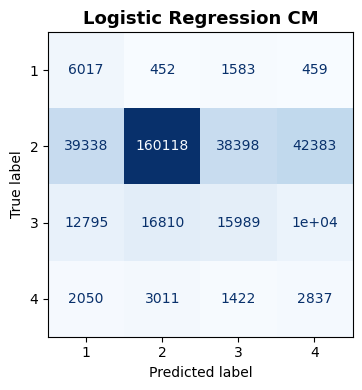

In [38]:
plot_confusion_matrix(model_lr, X_te, y_te, title="Logistic Regression CM")

Learning Curve

In [39]:
# plot_learning_curve(lr, X_tr, y_tr, title="LR Learning Curve")

### Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced", 
    random_state=42,
    n_jobs=-1
)

res_rf, model_rf = evaluate_model(
    rf, X_tr, y_tr, X_te, y_te,
    name="Random Forest"
)

res_rf

{'Model': 'Random Forest',
 'Train Acc': 0.7980887056375476,
 'Test Acc': 0.6836408670131251,
 'Test F1 (macro)': 0.5037303208633788,
 'Test Precision': 0.4560483168476943,
 'Test Recall': 0.7132281696595453,
 'CV Acc (mean)': np.float64(0.7822730016826582)}

In [41]:
print(classification_report(y_te, model_rf.predict(X_te), target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           1       0.27      0.86      0.41      8511
           2       0.96      0.67      0.79    280237
           3       0.39      0.72      0.51     55606
           4       0.21      0.60      0.31      9320

    accuracy                           0.68    353674
   macro avg       0.46      0.71      0.50    353674
weighted avg       0.83      0.68      0.72    353674



### Decision Tree

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=15,              
    min_samples_split=10,     
    min_samples_leaf=5,     
    class_weight='balanced',    
    random_state=42
)

res_dt, model_dt = evaluate_model(
    dt_model, X_tr, y_tr, X_te, y_te, name="Decision Tree"
)

res_dt

{'Model': 'Decision Tree',
 'Train Acc': 0.7972178336094948,
 'Test Acc': 0.6917585120760926,
 'Test F1 (macro)': 0.5099191193482379,
 'Test Precision': 0.46084971392525287,
 'Test Recall': 0.7228131163514804,
 'CV Acc (mean)': np.float64(0.7741808279706627)}

In [43]:
print(classification_report(y_te, model_dt.predict(X_te), target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           1       0.29      0.88      0.43      8511
           2       0.96      0.68      0.80    280237
           3       0.41      0.72      0.52     55606
           4       0.19      0.61      0.29      9320

    accuracy                           0.69    353674
   macro avg       0.46      0.72      0.51    353674
weighted avg       0.84      0.69      0.73    353674



### SVM

In [44]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

res_svm, model_svm = evaluate_model(
    svm, X_tr, y_tr, X_te, y_te,
    name="SVM (Linear)"
)

res_svm

{'Model': 'SVM (Linear)',
 'Train Acc': 0.5601287040961813,
 'Test Acc': 0.5555313650423837,
 'Test F1 (macro)': 0.33997928364986163,
 'Test Precision': 0.3406415569197897,
 'Test Recall': 0.4786307503045003,
 'CV Acc (mean)': np.float64(0.5577061898706537)}

In [45]:
print(classification_report(y_te, model_svm.predict(X_te)))

              precision    recall  f1-score   support

           1       0.10      0.58      0.17      8511
           2       0.88      0.58      0.70    280237
           3       0.30      0.46      0.36     55606
           4       0.08      0.29      0.13      9320

    accuracy                           0.56    353674
   macro avg       0.34      0.48      0.34    353674
weighted avg       0.75      0.56      0.62    353674



## Tuning Models

### Tuning Random Forest

Mencari hyperparameter terbaik untuk model Random Forest dengan RandomizedSearchCV

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=3,              
    verbose=2,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_tr, y_tr)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=3, min_samples_split=5, n_estimators=50; total time=   8.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=3, min_samples_split=5, n_estimators=50; total time=   8.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=3, min_samples_split=5, n_estimators=50; total time=   8.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=   8.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=   8.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=   7.7s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   6.3s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estima

In [47]:
best_rf = random_search.best_estimator_

res_rf, model_rf = evaluate_model(
    best_rf, X_tr, y_tr, X_te, y_te,
    name="Random Forest Tuned"
)

res_rf

{'Model': 'Random Forest Tuned',
 'Train Acc': 0.957035695477374,
 'Test Acc': 0.7969033629839909,
 'Test F1 (macro)': 0.6283998766660296,
 'Test Precision': 0.569826800355779,
 'Test Recall': 0.7359576060563088,
 'CV Acc (mean)': np.float64(0.8608557152582431)}

In [48]:
print(classification_report(y_te, model_rf.predict(X_te), target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           1       0.49      0.82      0.61      8511
           2       0.95      0.81      0.88    280237
           3       0.50      0.75      0.60     55606
           4       0.35      0.57      0.43      9320

    accuracy                           0.80    353674
   macro avg       0.57      0.74      0.63    353674
weighted avg       0.85      0.80      0.81    353674



### Tuning Decision Tree

Mencari hyperparameter terbaik untuk model Decision Tree dengan RandomizedSearchCV

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist_dt = {
    'max_depth': [5, 8, 10, 12, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 3, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist_dt,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

X_tr_sample = X_tr.sample(100000, random_state=42)
y_tr_sample = y_tr.loc[X_tr_sample.index]

random_search_dt.fit(X_tr_sample, y_tr_sample)

print("Best Params:", random_search_dt.best_params_)
print("Best Score:", random_search_dt.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 15, 'criterion': 'entropy'}
Best Score: 0.7258412608517171


In [50]:
best_dt = random_search_dt.best_estimator_

res_dt, model_dt = evaluate_model(
    best_dt, X_tr, y_tr, X_te, y_te,
    name="Decision Tree Tuned"
)

res_dt

{'Model': 'Decision Tree Tuned',
 'Train Acc': 0.7924588647836307,
 'Test Acc': 0.6846870281671822,
 'Test F1 (macro)': 0.49038815621203524,
 'Test Precision': 0.4474442990217475,
 'Test Recall': 0.7156918812419836,
 'CV Acc (mean)': np.float64(0.7684996082360345)}

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_te, model_dt.predict(X_te)))

              precision    recall  f1-score   support

           1       0.23      0.89      0.36      8511
           2       0.96      0.68      0.80    280237
           3       0.42      0.68      0.52     55606
           4       0.18      0.61      0.28      9320

    accuracy                           0.68    353674
   macro avg       0.45      0.72      0.49    353674
weighted avg       0.83      0.68      0.73    353674

